X Shape : (6537, 30, 132)
y Shape : (6537,)

Training Samples : 5229
Testing Samples : 1308

Class Weights:
{np.int64(0): np.float64(0.7020676691729323), np.int64(1): np.float64(1.7372093023255815)}


c:\Users\ADITI RAJ\Desktop\fall detection\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        50,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,393 (247.63 KB)

 Trainable params: 63,393 (247.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.7349 - loss: 0.5664 - val_accuracy: 0.7734 - val_loss: 0.4960
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8362 - loss: 0.4037 - val_accuracy: 0.8929 - val_loss: 0.3033
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8812 - loss: 0.3243 - val_accuracy: 0.8633 - val_loss: 0.3784
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9063 - loss: 0.2736 - val_accuracy: 0.8872 - val_loss: 0.3184
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9225 - loss: 0.2369 - val_accuracy: 0.9321 - val_loss: 0.2246
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9252 - loss: 0.2222 - val_accuracy: 0.9474 - val_loss: 0.1780
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9395 - loss: 0.1966 - val_accuracy: 0.9407 - val_loss: 0.2099
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9314 - loss: 0.2101 - val_acc

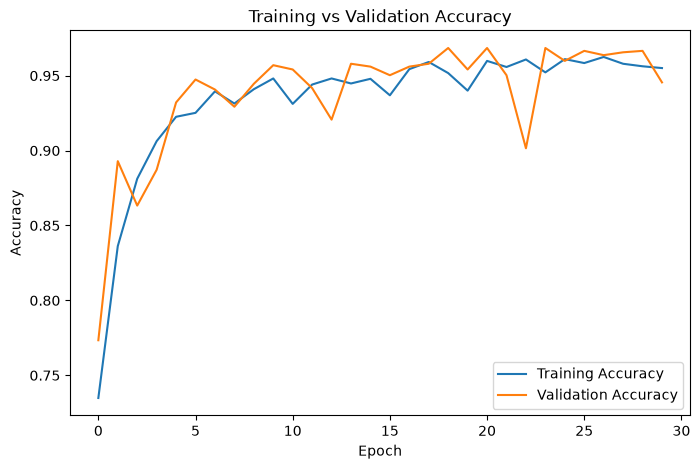

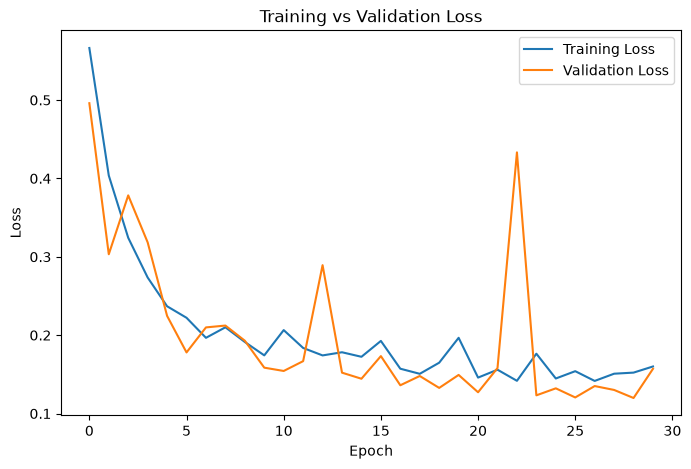

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ====================================
# CREATE MODEL FOLDER
# ====================================

os.makedirs("models", exist_ok=True)

# ====================================
# LOAD DATA
# ====================================

X = np.load("processed_data/X.npy")
y = np.load("processed_data/y.npy")

print("X Shape :", X.shape)
print("y Shape :", y.shape)

# ====================================
# TRAIN TEST SPLIT
# ====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))

# ====================================
# COMPUTE CLASS WEIGHTS
# ====================================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("\nClass Weights:")
print(class_weights)

# ====================================
# BUILD LSTM MODEL
# ====================================

model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(30, 132),
        return_sequences=True
    )
)

model.add(Dropout(0.3))

model.add(LSTM(32))

model.add(Dropout(0.3))

model.add(Dense(16, activation="relu"))

model.add(Dense(1, activation="sigmoid"))

# ====================================
# COMPILE
# ====================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ====================================
# EARLY STOPPING
# ====================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# ====================================
# TRAIN
# ====================================

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights
)

# ====================================
# SAVE MODEL
# ====================================

model.save("models/fall_model.keras")

print("\nModel Saved Successfully!")

# ====================================
# TEST
# ====================================

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy :", accuracy)

# ====================================
# PREDICTIONS
# ====================================

predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

print("\nClassification Report\n")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, predictions))

# ====================================
# ACCURACY SCORE
# ====================================

acc = accuracy_score(y_test, predictions)
print("\nAccuracy Score :", acc)

# ====================================
# PLOT ACCURACY
# ====================================

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

# ====================================
# PLOT LOSS
# ====================================

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()